In [3]:
from itertools import chain
latent_lists = [[106, 119], [106, 119], [106, 117, 128, 141], [106], [106, 117], [106, 117, 128, 139], [106], [106, 117], [106, 117, 128], [106, 117], [106, 117], [106, 119, 130, 143, 154], [106, 117, 128, 139], [106], [106, 117], [106, 117, 128], [106, 117], [106], [106], [106, 117], [106, 117, 128, 139], [106, 117], [106], [106, 119, 130, 141, 154, 165], [106, 117], [106, 117, 128], [106, 117, 128], [106, 117, 128], [106, 117], [106, 117, 128], [106, 119, 132, 144], [106, 117, 128]]

indices = sorted(list(set(list(chain.from_iterable(latent_lists)))))
compute_ranges = [(0, indices[0])] + [(indices[i], indices[i+1]) for i in range(len(indices)-1)]
compute_ranges

[(0, 106),
 (106, 117),
 (117, 119),
 (119, 128),
 (128, 130),
 (130, 132),
 (132, 139),
 (139, 141),
 (141, 143),
 (143, 144),
 (144, 154),
 (154, 165)]

In [2]:
compute_ranges

[(0, 106), (106, 117), (117, 128), (128, 139), (139, 154), (154, 165)]

In [4]:
latent_lists.pop(0)

[106, 119]

In [5]:
latent_lists

[[106, 119],
 [106, 117, 128, 141],
 [106],
 [106, 117],
 [106, 117, 128, 139],
 [106],
 [106, 117],
 [106, 117, 128],
 [106, 117],
 [106, 117],
 [106, 119, 130, 143, 154],
 [106, 117, 128, 139],
 [106],
 [106, 117],
 [106, 117, 128],
 [106, 117],
 [106],
 [106],
 [106, 117],
 [106, 117, 128, 139],
 [106, 117],
 [106],
 [106, 119, 130, 141, 154, 165],
 [106, 117],
 [106, 117, 128],
 [106, 117, 128],
 [106, 117, 128],
 [106, 117],
 [106, 117, 128],
 [106, 119, 132, 144],
 [106, 117, 128]]

In [1]:
from utils import BatchComputeRangeIterator, ComputeRange

ins1_ranges = [ComputeRange(0, 78, "lang"), ComputeRange(78, 80, "latent"), ComputeRange(80, 89, "lang"), ComputeRange(89, 91, "latent"), ComputeRange(91, 100, "lang")]
ins2_ranges = [ComputeRange(0, 78, "lang"), ComputeRange(78, 85, "latent"), ComputeRange(85, 90, "lang"), ComputeRange(90, 95, "latent"), ComputeRange(95, 100, "lang")]
ins3_ranges = [ComputeRange(0, 78, "lang"), ComputeRange(78, 90, "latent"), ComputeRange(90, 95, "lang"), ComputeRange(95, 98, "latent"), ComputeRange(98, 100, "lang")]

c_iter = BatchComputeRangeIterator([ins1_ranges, ins2_ranges, ins3_ranges])

In [2]:
for next_ranges in c_iter:
    print(next_ranges)

((ComputeRange(start=0, end=78, mode='lang'), [0, 1, 2]), None)
(None, (ComputeRange(start=78, end=80, mode='latent'), [0, 1, 2]))
((ComputeRange(start=80, end=89, mode='lang'), [0]), (ComputeRange(start=80, end=85, mode='latent'), [1, 2]))
((ComputeRange(start=85, end=90, mode='lang'), [1]), (ComputeRange(start=85, end=90, mode='latent'), [2]))
(None, (ComputeRange(start=89, end=91, mode='latent'), [0]))
((ComputeRange(start=90, end=95, mode='lang'), [2]), (ComputeRange(start=90, end=95, mode='latent'), [1]))
((ComputeRange(start=91, end=100, mode='lang'), [0]), None)
((ComputeRange(start=95, end=100, mode='lang'), [1]), (ComputeRange(start=95, end=98, mode='latent'), [2]))
((ComputeRange(start=98, end=100, mode='lang'), [2]), None)


In [3]:
from dataset import get_cot_latent_dataset, get_dataset
from transformers import AutoTokenizer
import yaml
from utils import Config

with open("configs/coconut/math_coconut_qwen2.5-0.5b.yaml") as f:
    config_dict = yaml.safe_load(f)

configs = Config(config_dict)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.add_tokens("<|start-latent|>")
tokenizer.add_tokens("<|end-latent|>")
tokenizer.add_tokens("<|latent|>")
latent_id = tokenizer.convert_tokens_to_ids("<|latent|>")
start_id = tokenizer.convert_tokens_to_ids("<|start-latent|>")
end_id = tokenizer.convert_tokens_to_ids("<|end-latent|>")

base_dataset_train = get_dataset(
    "data/math/math_train.json", tokenizer, max_size=100000000
)

dataset_train = get_cot_latent_dataset(
    0,
    base_dataset_train,
    configs,
    start_id,
    latent_id,
    end_id,
    no_special_marker=configs.cot or configs.no_cot or configs.no_thoughts,
    shuffle=True,
)

Map (num_proc=32):   0%|          | 0/10000 [00:00<?, ? examples/s]

Map (num_proc=32):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [7]:
max_length = max(
    [len(item["input_ids"]) for item in dataset_train]
)
import numpy as np

lengths = np.array([len(item["input_ids"]) for item in dataset_train])


np.int64(168)

<Axes: ylabel='Count'>

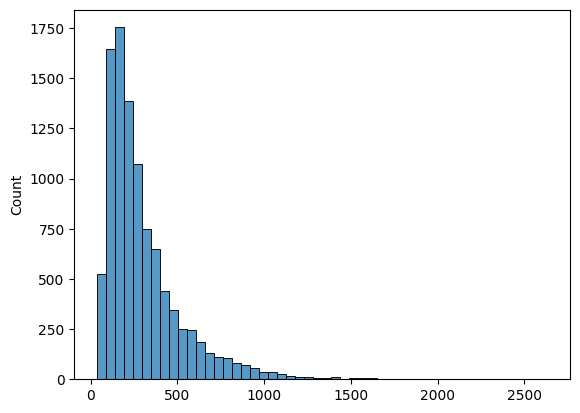

In [9]:
import seaborn as sns

sns.histplot(lengths, bins=50)

In [1]:
import json

with open("data/gsm/gsm_train.json", "r") as f:
    data = json.load(f)

data[0]

{'question': 'Out of 600 employees in a company, 30% got promoted while 10% received bonus. How many employees did not get either a promotion or a bonus?',
 'steps': ['<<600*30/100=180>>',
  '<<600*10/100=60>>',
  '<<180+60=240>>',
  '<<600-240=360>>'],
 'answer': '360'}

In [2]:
num_steps = [len(item["steps"]) for item in data]
min(num_steps), max(num_steps), sum(num_steps)/len(num_steps)

(1, 13, 2.598244385664644)

<Axes: ylabel='Count'>

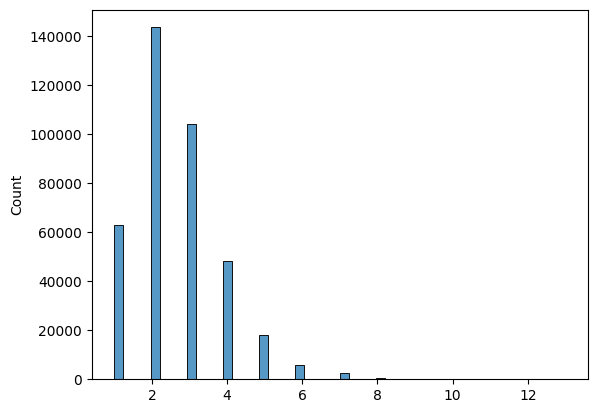

In [3]:
import seaborn as sns

sns.histplot(num_steps, bins=50)

In [4]:
with open("data/math/math_train.json", "r") as f:
    math_data = json.load(f)

math_data[0]

{'problem': 'Chris and Nathan order a giant cookie together. If Chris eats $\\frac{2}{7}$ of the cookie and Nathan eats $\\frac{3}{5}$ of the cookie, what fraction of the original cookie is left?',
 'level': 'Level 3',
 'type': 'Prealgebra',
 'solution': "The total amount eaten is $\\frac{2}{7} + \\frac{3}{5}$. The denominators have a common multiple of 35, so this is equivalent to $\\frac{10}{35} + \\frac{21}{35} = \\frac{10 + 21}{35} = \\frac{31}{35}$. Thus, the amount that Chris and Nathan didn't eat is $1 - \\frac{31}{35} = \\frac{35}{35} - \\frac{31}{35} = \\boxed{\\frac{4}{35}}.$",
 'steps': ['The total amount eaten is $\\frac{2}{7} + \\frac{3}{5}$.',
  'The denominators have a common multiple of 35, so this is equivalent to $\\frac{10}{35} + \\frac{21}{35} = \\frac{10 + 21}{35} = \\frac{31}{35}$.',
  "Thus, the amount that Chris and Nathan didn't eat is $1 - \\frac{31}{35} = \\frac{35}{35} - \\frac{31}{35} = \\boxed{\\frac{4}{35}}.$"],
 'num_steps': 3,
 'split_flags': [],
 'spli

In [5]:
num_steps = [len(item["steps"]) for item in math_data]
min(num_steps), max(num_steps), sum(num_steps)/len(num_steps)

(1, 93, 5.3292631578947365)

<Axes: ylabel='Count'>

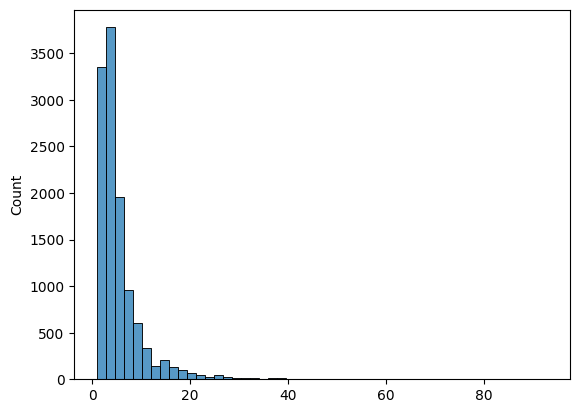

In [6]:
import seaborn as sns

sns.histplot(num_steps, bins=50)

In [9]:
len([item for item in math_data if len(item["steps"]) < 15])

11243